In [2]:
import pandas as pd

In [3]:

ord = pd.read_csv("olist_orders_dataset.csv")
cus = pd.read_csv("olist_customers_dataset.csv")


In [4]:
ord.columns


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [5]:
cus.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [6]:
leftmerge = ord.merge(cus ,on='customer_id' , how='left')
print(leftmerge)

                               order_id                       customer_id  \
0      e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1      53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2      47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3      949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4      ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
...                                 ...                               ...   
99436  9c5dedf39a927c1b2549525ed64a053c  39bd1228ee8140590ac3aca26f2dfe00   
99437  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
99438  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
99439  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
99440  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

      order_status order_purchase_timestamp    order_approved_at  \
0      

In [7]:
len(ord)


99441

In [8]:
len(leftmerge)

99441

In [9]:
cus['customer_id'].duplicated().sum()

np.int64(0)

In [10]:
pay = pd.read_csv("olist_order_payments_dataset.csv")
itm = pd.read_csv("olist_order_items_dataset.csv")

In [11]:
pay.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [12]:
itm.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [13]:
itm['order_id'].duplicated().sum()


np.int64(13984)

In [14]:
pay['order_id'].duplicated().sum()

np.int64(4446)

In [15]:
merge2 = leftmerge.merge(itm ,on='order_id', how='left')
print(merge2)

                                order_id                       customer_id  \
0       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1       53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2       47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3       949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4       ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
...                                  ...                               ...   
113420  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
113421  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
113422  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
113423  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
113424  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

       order_status order_purchase_timestamp    order_approved_

In [16]:
len(leftmerge)

99441

In [17]:
len(merge2)

113425

In [18]:
# Sélection des colonnes numériques directement disponibles dans merge2
cols_num = ["price", "freight_value"]

# Matrice de corrélation
corr_matrix = merge2[cols_num].corr()
print(corr_matrix)

                  price  freight_value
price          1.000000       0.414204
freight_value  0.414204       1.000000


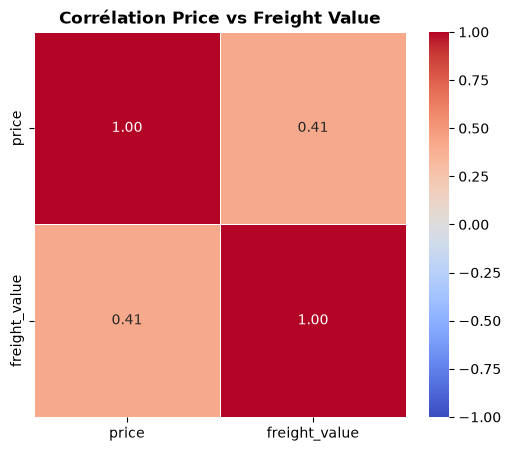

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
)
plt.title("Corrélation Price vs Freight Value", weight="bold")
plt.show()

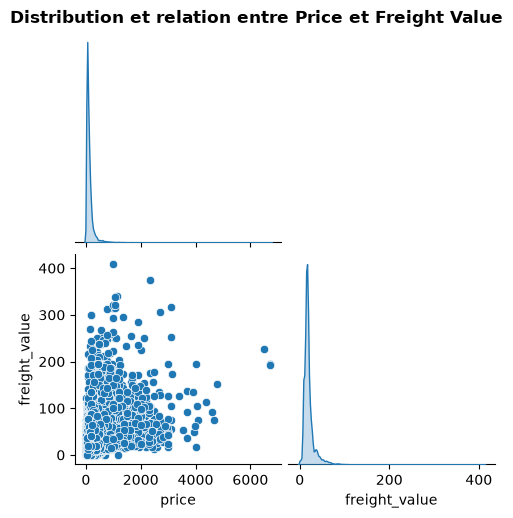

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualisation des distributions et des relations
sns.pairplot(
    merge2[['price', 'freight_value']].dropna(),
    diag_kind='kde', # Courbe de densité sur la diagonale
    corner=True # Supprime la partie supérieure redondante
)

plt.suptitle("Distribution et relation entre Price et Freight Value", y=1.02, weight='bold')
plt.show()

In [21]:
merge2.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [22]:
pd.pivot_table(merge2 , index=['customer_state'] , values=['price'] , aggfunc='mean').sort_values(by = "price" , ascending = False)

,price
customer_state,
PB,191.475216
AL,180.889212
AC,173.727717
RO,165.973525
PA,165.692417
AP,164.320732
PI,160.358081
TO,157.529333
RN,156.965936


In [23]:
pd.pivot_table(
    merge2,
    index=['customer_state'],
    columns=['order_status'],
    values=['price'],
    aggfunc='sum',
    fill_value=0
)

price                                                     \
order_status   approved  canceled created   delivered  invoiced processing   
customer_state                                                               
AC                  0.0      0.00     0.0    15930.97      0.00       0.00   
AL                  0.0      0.00     0.0    78855.72    108.75     248.69   
AM                  0.0      0.00     0.0    22155.84      0.00       0.00   
AP                  0.0      0.00     0.0    13374.81      0.00      99.49   
BA                  0.0   4241.16     0.0   493584.14   1836.37    2279.47   
CE                  0.0    990.65     0.0   219757.38    155.00    1390.78   
DF                  0.0   1717.49     0.0   296498.41    134.92     611.49   
ES                  0.0   1505.18     0.0   268643.45   1782.75      83.50   
GO                  0.0   6721.49     0.0   282836.70    436.78    1066.66   
MA                  0.0    356.60     0.0   117009.38     57.80       0.00   
MG                 39.7  11640.84     0.0  1552481.83   8288.42    5190.26   
MS                  0.0     57.99     0.0   115429.97    389.00     495.80   
MT                  0.0    140.00     0.0   152191.62   1599.00     609.00   
PA                  0.0    126.69     0.0   174470.59    756.80     498.89   
PB                  0.0    393.98     0.0   112586.82     47.81     409.80   
PE                  0.0   1048.09     0.0   251889.49   2286.28    2278.30   
PI                  0.0    253.99     0.0    84721.00    646.93     628.90   
PR                  0.0   6200.70     0.0   666063.51   2440.37    2593.43   
RJ                  0.0  12169.35     0.0  1759651.13   5129.62    7340.18   
RN                  0.0      0.00     0.0    82105.66      0.00     125.90   
RO                  0.0    109.00     0.0    45682.76    125.00     223.88   
RR                  0.0     89.99     0.0     7057.47      0.00       0.00   
RS                  0.0   7494.34     0.0   728897.47   4917.82    2025.23   
SC                  0.0   1975.06     0.0   507012.13   2904.67    4249.96   
SE                  0.0      0.00     0.0    56574.19     21.90       0.00   
SP                169.9  37788.93     0.0  5067633.16  27460.38   27910.61   
TO                  0.0    213.75     0.0    48402.51      0.00      79.00   

                                      
order_status     shipped unavailable  
customer_state                        
AC                 51.98        0.00  
AL               1101.65        0.00  
AM                201.00        0.00  
AP                  0.00        0.00  
BA               9408.85        0.00  
CE               4960.90        0.00  
DF               3641.63        0.00  
ES               3022.43        0.00  
GO               3530.32        0.00  
MA               2224.44        0.00  
MG               7507.99      158.99  
MS                439.88        0.00  
MT               1913.91        0.00  
PA               3094.84        0.00  
PB               1829.67        0.00  
PE               5285.87        0.00  
PI                663.26        0.00  
PR               5785.75        0.00  
RJ              39502.49      299.90  
RN                803.42        0.00  
RO                  0.00        0.00  
RR                681.97        0.00  
RS               6719.26      249.90  
SC               4411.52        0.00  
SE               2324.76        0.00  
SP              40693.17     1298.90  
TO                926.48        0.00

In [24]:
merge3 = merge2.merge(pay, on='order_id', how='left')
print(merge3)

                                order_id                       customer_id  \
0       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3       53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4       47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
...                                  ...                               ...   
118429  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
118430  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
118431  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
118432  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
118433  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

       order_status order_purchase_timestamp    order_approved_

In [25]:
len(merge2)

113425

In [26]:
len(merge3)

118434

In [27]:
merge3.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value'],
      dtype='str')

In [28]:
cols = ['price','freight_value','payment_value']
corr = merge3[cols].corr()
print(corr)

                  price  freight_value  payment_value
price          1.000000       0.415813       0.739501
freight_value  0.415813       1.000000       0.373891
payment_value  0.739501       0.373891       1.000000


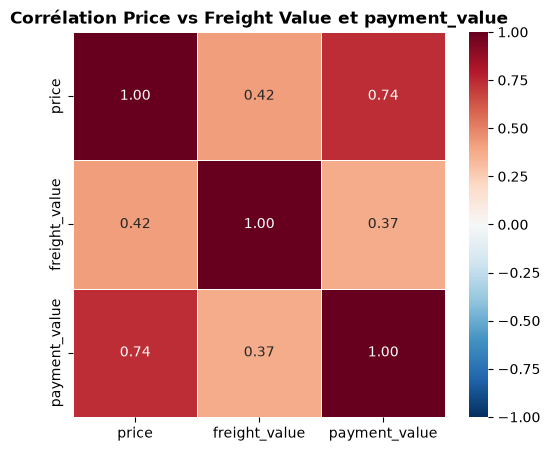

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
)

plt.title("Corrélation Price vs Freight Value et payment_value", weight="bold")
plt.show()

# Mini-rapport de conclusions — Projet Olist

## Contexte
Analyse du dataset e-commerce brésilien Olist, en fusionnant 3 tables (`orders`, `customers`, `items`, `payments`) pour étudier la structure des commandes et les corrélations entre variables numériques (prix, frais de port, montant payé).

## Méthodologie
1. **Fusion 1 — `orders` + `customers`** (relation **un-à-un**) : chaque commande a un seul `customer_id`, sans doublon (`cus['customer_id'].duplicated().sum() = 0`). Le merge (`how='left'`) conserve donc les 99 441 lignes d'origine.
2. **Fusion 2 — + `items`** (relation **un-à-plusieurs**) : une commande peut contenir plusieurs articles (`order_id` dupliqué 13 984 fois dans `items`). Le merge fait donc passer le nombre de lignes de 99 441 à 113 425 (une ligne par article, plusieurs lignes par commande multi-articles).
3. **Fusion 3 — + `payments`** (relation **un-à-plusieurs**) : une commande peut être réglée en plusieurs paiements (`order_id` dupliqué 4 446 fois dans `payments`). Nouvelle hausse du nombre de lignes, de 113 425 à 118 434.
4. **Corrélations** : calcul de matrices de corrélation sur les variables numériques (`price`, `freight_value`, puis `payment_value`) et visualisation via heatmaps Seaborn.

## Résultats clés
- **Structure des fusions** : le passage de 99 441 → 113 425 → 118 434 lignes illustre concrètement l'effet des relations un-à-plusieurs : chaque fusion avec une table détail (items, payments) démultiplie les lignes, contrairement à la fusion un-à-un avec `customers` qui préserve le nombre de commandes.
- **Corrélation price / freight_value** : corrélation modérée (**0,41**) — un article plus cher tend à coûter un peu plus cher à expédier, mais le lien reste loin d'être mécanique (poids/volume jouent aussi).
- **Corrélation price / payment_value** : corrélation forte (**0,74**) — logique, le montant payé dépend directement du prix de l'article.
- **Corrélation freight_value / payment_value** : corrélation plus faible (**0,37**) — les frais de port pèsent moins que le prix dans le montant total payé.
- **Prix moyen par état** : les états les plus chers en prix moyen (PB, AL, AC) sont aussi parmi les plus éloignés des grands centres logistiques, cohérent avec des frais de port et des prix plus élevés en périphérie.

## Conclusion
Les fusions successives montrent l'importance de distinguer relations un-à-un et un-à-plusieurs : une jointure un-à-plusieurs mal anticipée peut fausser des agrégats (doublons de commande) si on ne raisonne pas au bon niveau de granularité (commande vs article vs paiement). Sur le plan des corrélations, le prix reste le facteur le plus déterminant du montant payé (0,74), tandis que les frais de port n'expliquent qu'une fraction limitée de la variance des prix (0,41) et des paiements (0,37) — plusieurs autres facteurs (poids, distance, catégorie de produit) entrent probablement en jeu.